In [ ]:
from google.colab import files
uploaded=files.upload()

Saving BBC News Train.csv to BBC News Train.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("BBC News Train.csv")
df=pd.DataFrame(data)
df.head(10)

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business
5,1582,howard truanted to play snooker conservative...,politics
6,651,wales silent on grand slam talk rhys williams ...,sport
7,1797,french honour for director parker british film...,entertainment
8,2034,car giant hit by mercedes slump a slump in pro...,business
9,1866,fockers fuel festive film chart comedy meet th...,entertainment


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


In [ ]:
df.isnull().sum()

,0
ArticleId,0
Text,0
Category,0


In [ ]:
df['Category'].value_counts()

,count
Category,
sport,346
business,336
politics,274
entertainment,273
tech,261


In [ ]:
x=df['Text']
y=df['Category']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
x=df['Text']
x_tfidf=tfidf.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_tfidf,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)

MultinomialNB()

In [ ]:
nb.score(x_test,y_test)*100,nb.score(x_train,y_train)*100


(95.63758389261746, 99.41275167785236)

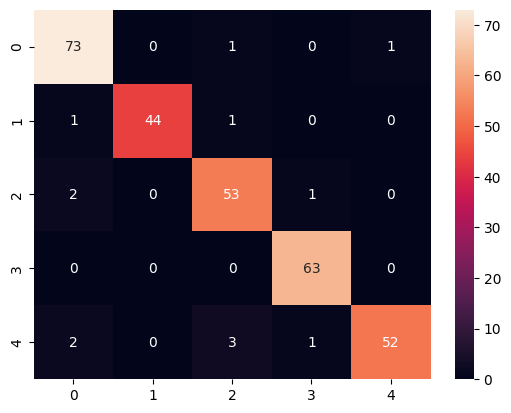

In [ ]:
from sklearn.metrics import confusion_matrix,f1_score,precision_score,recall_score
y_pred=nb.predict(x_test)
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot=True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred)*100)

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298
               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298
      

In [ ]:
f1=f1_score(y_test,y_pred,average="weighted")*100
p=precision_score(y_test,y_pred,average="weighted")*100
r=recall_score(y_test,y_pred,average="weighted")*100
print("f1_score:",f1)
print("precision_score:",p)
print("recall_score:",r)

f1_score: 95.62904295627416
precision_score: 95.74896655178125
recall_score: 95.63758389261746


In [ ]:
import numpy as np
news = input("Enter the news article: ")

news_tfidf = tfidf.transform([news])

prediction = nb.predict(news_tfidf)
print("Predicted category:", prediction[0])


probs = nb.predict_proba(news_tfidf)[0]
top3_idx = np.argsort(probs)[-3:][::-1]

print("\nTop 3 Predictions:")
for i in top3_idx:
    print(f"{nb.classes_[i]}: {probs[i]*100:.2f}%")

Enter the news article: Apple has launched a new AI-powered smartphone with advanced camera features and improved battery life. The company expects strong sales in global markets.
Predicted category: business

Top 3 Predictions:
business: 35.13%
tech: 30.66%
entertainment: 15.27%
